# **imports**

In [53]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import PIL.Image as Image
import os
import cv2
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torch
from torch import nn
import torch.nn.functional as F

from SelfAttention.self_attention import SelfAttention
from SelfAttention.MLP import MLP

from TransformerBlocks.ImageTransformerBlock import ImageTransformerBlock
from TransformerBlocks.PointTransformerBlock import PointTransformerBlock

# load **DATA**

In [54]:
def uniform_sampling(contour, n):
    contour = np.asarray(contour, dtype=np.float32)

    if not np.allclose(contour[0], contour[-1]):
        contour = np.vstack([contour, contour[0]])

    # Segmentvektoren + Längen
    seg = np.diff(contour, axis=0)
    seg_len = np.linalg.norm(seg, axis=1)

    # kumulative Bogenlänge
    s = np.concatenate([[0], np.cumsum(seg_len)])

    # Zielpositionen
    t = np.linspace(0, s[-1], n, endpoint=False)

    # Segmentindex
    idx = np.searchsorted(s, t, side='right') - 1
    idx = np.clip(idx, 0, len(seg)-1)

    # lokale Interpolation
    local_t = (t - s[idx]) / seg_len[idx]

    return contour[idx] + seg[idx] * local_t[:, None]

In [55]:
import random


class PH2ContourDataset(Dataset):
    def __init__(self, base_path, n_punkte=200, img_size=(256, 256)):
        """
        base_path: Der Pfad zum Ordner "PH2 Dataset images" 
                   (z.B. "C:/Users/.../PH2Dataset/PH2 Dataset images")
        """
        self.base_path = base_path
        self.n_punkte = n_punkte
        self.img_size = img_size
        self.samples = []

        # 1. Die exakte Ordnerstruktur des PH2-Datasets auslesen
        for folder_name in os.listdir(base_path):
            folder_path = os.path.join(base_path, folder_name)
            
            # Überprüfen, ob es ein Ordner ist (z.B. "IMD002")
            if os.path.isdir(folder_path):
                # Die Pfade exakt nach der PH2-Namenskonvention zusammenbauen
                img_path = os.path.join(folder_path, f"{folder_name}_Dermoscopic_Image", f"{folder_name}.bmp")
                mask_path = os.path.join(folder_path, f"{folder_name}_lesion", f"{folder_name}_lesion.bmp")
                
                # Nur hinzufügen, wenn beide Dateien auch wirklich existieren
                if os.path.exists(img_path) and os.path.exists(mask_path):
                    self.samples.append({
                        'img_path': img_path,
                        'mask_path': mask_path
                    })

        print(f"Datensatz geladen: {len(self.samples)} Bilder und Masken gefunden.")

        # 2. PyTorch Transformationen für das Konditionierungs-Bild
        self.img_transform = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) 
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # --- A. BILD VERARBEITEN ---
        img = Image.open(sample['img_path']).convert("RGB")
        mask = Image.open(sample['mask_path']).convert("L") 

        # --- SYNCHRONE AUGMENTATION ---
        
        # 1. Horizontaler Flip (Links/Rechts) - BEIDE gleich!
        if random.random() < 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)
            
        # 2. Vertikaler Flip (Oben/Unten) - BEIDE gleich!
        if random.random() < 0.5:
            img = TF.vflip(img)
            mask = TF.vflip(mask)

        # 3. Rotation & Zoom
        angle = random.uniform(-45, 45)
        translate = (random.randint(-20, 20), random.randint(-20, 20))
        scale = random.uniform(0.9, 1.1)

        img = TF.affine(img, angle=angle, translate=translate, scale=scale, shear=0)
        mask = TF.affine(mask, angle=angle, translate=translate, scale=scale, shear=0)

        # 4. Farb-Jitter (Nur fürs Bild, die Maske MUSS schwarz-weiß bleiben)
        img = transforms.ColorJitter(brightness=0.2, contrast=0.2)(img)

        # --- RESIZE FIX ---
        # Wir nutzen TF.resize für die Maske, damit es EXAKT so skaliert wie dein img_transform!
        # Interpolation NEAREST ist wichtig, damit die Maske keine grauen Kanten bekommt.
        mask = TF.resize(mask, self.img_size, interpolation=transforms.InterpolationMode.NEAREST)
        img_tensor = self.img_transform(img) # Macht Resize, ToTensor und Normalize

        # --- B. KONTUR EXTRAHIEREN ---
        mask_np = np.array(mask)
        mask_binary = (mask_np > 0).astype(np.uint8) * 255
        contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        
        contour = max(contours, key=cv2.contourArea).squeeze()
        points = uniform_sampling(contour, self.n_punkte) 

        # --- C. KOORDINATEN NORMALISIEREN [-1, 1] ---
        # ACHTUNG: PyTorch img_size ist (Höhe, Breite). 
        # OpenCV Punkte sind aber (X=Breite, Y=Höhe).
        H, W = self.img_size # Hier richtig entpacken!
        
        points_norm = points.astype(np.float32)
        
        # X-Koordinaten (Breite) normalisieren
        points_norm[:, 0] = points_norm[:, 0] / (W - 1)
        # Y-Koordinaten (Höhe) normalisieren
        points_norm[:, 1] = points_norm[:, 1] / (H - 1)
        
        points_norm = points_norm * 2.0 - 1.0

        points_tensor = torch.tensor(points_norm, dtype=torch.float32)

        return img_tensor, points_tensor

In [ ]:
# 1. Dataset initialisieren
dataset = PH2ContourDataset(base_path="..\PH2Dataset\PH2 Dataset images", n_punkte=200, img_size=(576, 768))

# 2. DataLoader erstellen (z.B. 16 Bilder gleichzeitig verarbeiten)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, drop_last=True)

# 3. Testen, ob alles klappt:
for batch_images, batch_points in dataloader:
    print("Bild-Batch Form:", batch_images.shape)  
    print("Punkt-Batch Form:", batch_points.shape)     


Datensatz geladen: 200 Bilder und Masken gefunden.
Bild-Batch Form: torch.Size([16, 3, 576, 768])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 768])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 768])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 768])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 768])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 768])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 768])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 768])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 768])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 768])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 768])
Pu

In [57]:
def verify_dataset(batch_images, batch_points, num_samples=4):
    """
    Plottet Bilder und Punkte aus dem PyTorch DataLoader zur Überprüfung.
    batch_images: Tensor der Form (B, 3, H, W) im Bereich [-1, 1]
    batch_points: Tensor der Form (B, n_punkte, 2) im Bereich [-1, 1]
    """
    # Sicherstellen, dass wir nicht mehr Samples plotten, als im Batch sind
    batch_size, channels, H, W = batch_images.shape
    num_samples = min(batch_size, num_samples)
    
    fig, axes = plt.subplots(1, num_samples, figsize=(16, 5))
    if num_samples == 1:
        axes = [axes] # Fallback, falls nur 1 Bild geplottet wird
        
    for i in range(num_samples):
        # --- 1. BILD DENORMALISIEREN ---
        # Von [-1, 1] zurück auf [0, 1] für Matplotlib
        img = batch_images[i].cpu().numpy()
        # Form ändern von (3, H, W) zu (H, W, 3)
        img = img.transpose(1, 2, 0)
        img = (img * 0.5) + 0.5 
        img = np.clip(img, 0, 1) # Sicherheitshalber auf 0-1 abschneiden
        
        # --- 2. PUNKTE DENORMALISIEREN ---
        # Von [-1, 1] zurück auf absolute Pixelkoordinaten
        pts = batch_points[i].cpu().numpy()
        pts_x = (pts[:, 0] + 1.0) / 2.0 * (W - 1)
        pts_y = (pts[:, 1] + 1.0) / 2.0 * (H - 1)
        
        # --- 3. PLOTTEN ---
        axes[i].imshow(img)
        # Punkte als rote Punkte ('r.') und mit Linien verbunden ('-') zeichnen
        axes[i].plot(pts_x, pts_y, 'r.-', markersize=3, linewidth=1)
        
        # Die Kontur optisch schließen (letzten Punkt mit erstem verbinden)
        axes[i].plot([pts_x[-1], pts_x[0]], [pts_y[-1], pts_y[0]], 'r-', linewidth=1)
        
        axes[i].axis("off")
        axes[i].set_title(f"Sample {i+1}")
        
    plt.tight_layout()
    plt.show()


Bild-Batch Form: torch.Size([16, 3, 576, 768])
Punkt-Batch Form: torch.Size([16, 200, 2])


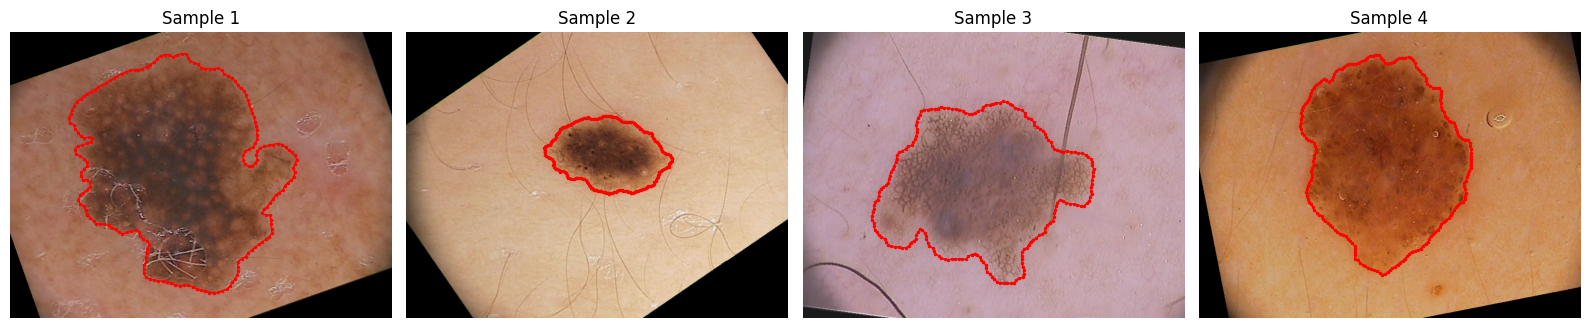

In [58]:

for batch_images, batch_points in dataloader:
    print("Bild-Batch Form:", batch_images.shape)  # Wird (16, 3, 576, 766) sein
    print("Punkt-Batch Form:", batch_points.shape) # Wird (16, 200, 2) sein
    
    # Plot aufrufen
    verify_dataset(batch_images, batch_points)
    break # Bricht nach dem ersten Batch ab

# **UNET**

## Blocks

<img src="../images/residualBlock + UpSample.png" width="15%">


### Residual Block

<img src="../images/residualBlock.png" width="15%"> 

In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, groupnorm_num_groups=16):
        super().__init__()
        
        self.groupnorm1 = nn.GroupNorm(groupnorm_num_groups, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same")

        self.groupnorm2 = nn.GroupNorm(groupnorm_num_groups, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same")

        self.resize_channels = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        residual_connection = x                             
        
        x = self.groupnorm1(x)
        x = F.silu(x)
        x = self.conv1(x)


        x = self.groupnorm2(x)
        x = F.silu(x)
        x = self.conv2(x)                                   

        x = x + self.resize_channels(residual_connection)   
        return x

### Upsample Block



In [60]:
class UpsampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding="same")
        )

    def forward(self, x):
        return self.upsample(x)

## **UNET**

<img src="../images/U-Net_2.png" width="40%">

In [61]:
class FeatureUNET(nn.Module):
    def __init__(self, in_channels=3, out_features=64, start_dim=64, dim_mults=(1,2,4), residual_blocks_per_group=1, groupnorm_num_groups=16):
        super().__init__()

        self.input_image_channels = in_channels
        channel_sizes = [start_dim * i for i in dim_mults]
        starting_channel_size, ending_channel_size = channel_sizes[0], channel_sizes[-1]

        self.encoder_config = []

        for idx, d in enumerate(channel_sizes):
            for _ in range(residual_blocks_per_group):
                self.encoder_config.append(((d, d), "residual"))

            self.encoder_config.append(((d,d), "downsample"))

            self.encoder_config.append((d, "attention"))

            if idx < len(channel_sizes) - 1:
                self.encoder_config.append(((d, channel_sizes[idx+1]), "residual"))

        self.bottleneck_config = []
        for _ in range(residual_blocks_per_group):
            self.bottleneck_config.append(((ending_channel_size, ending_channel_size), "residual"))

        out_dim = ending_channel_size
        reversered_encoder_config = self.encoder_config[::-1]

        self.decoder_config = []
        for idx, (metadata, l_type) in enumerate(reversered_encoder_config):
            
            if l_type != "attention":
                enc_in_channels, enc_out_channels = metadata
                self.decoder_config.append(
                    (
                        (out_dim+enc_out_channels, enc_in_channels), "residual"
                    )
                )

                if l_type == "downsample":
                    self.decoder_config.append(
                        (
                            (enc_in_channels, enc_in_channels), "upsample"
                        )
                    )
                out_dim = enc_in_channels

            else:
                in_channels = metadata
                self.decoder_config.append(
                    (
                        in_channels, "attention"
                    )
                )
        self.decoder_config.append(((starting_channel_size * 2, starting_channel_size), "residual"))

        ### ACTUALLY BUILD MODEL ###
        self.conv_in_proj = nn.Conv2d(self.input_image_channels, starting_channel_size, kernel_size=3, padding="same")

        self.encoder = nn.ModuleList()
        for metadata, l_type in self.encoder_config:
            if l_type == "residual":
                in_channels, out_channels = metadata
                # Zeit-Parameter entfernt!
                self.encoder.append(ResidualBlock(in_channels, out_channels, groupnorm_num_groups))
            elif l_type == "downsample":
                in_channels, out_channels = metadata
                self.encoder.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1))
            elif l_type == "attention":
                in_channels = metadata
                self.encoder.append(ImageTransformerBlock(in_channels))

        self.bottleneck = nn.ModuleList()
        for (in_channels, out_channels), _ in self.bottleneck_config:
            # Zeit-Parameter entfernt!
            self.bottleneck.append(ResidualBlock(in_channels, out_channels, groupnorm_num_groups))

        self.decoder = nn.ModuleList()
        for metadata, l_type in self.decoder_config:
            if l_type == "residual":
                in_channels, out_channels = metadata
                # Zeit-Parameter entfernt!
                self.decoder.append(ResidualBlock(in_channels, out_channels, groupnorm_num_groups))
            elif l_type == "upsample":
                in_channels, out_channels = metadata
                self.decoder.append(UpsampleBlock(in_channels, out_channels))
            elif l_type == "attention":
                in_channels = metadata
                self.decoder.append(ImageTransformerBlock(in_channels))

        # NEU: Wir spucken nicht input_image_channels (3) aus, sondern out_features (64)!
        self.conv_out_proj = nn.Conv2d(starting_channel_size, out_features, kernel_size=3, padding="same")

    def forward(self, x): # NEU: Keine time_embeddings mehr!
        residuals = []

        x = self.conv_in_proj(x)
        residuals.append(x)  

        for module in self.encoder:
            if isinstance(module, ResidualBlock):
                x = module(x) # 
                residuals.append(x)
            elif isinstance(module, nn.Conv2d):  
                x = module(x)
                residuals.append(x)
            else:  
                x = module(x)

        for module in self.bottleneck:
            x = module(x) 

        for module in self.decoder:
            if isinstance(module, ResidualBlock):
                residual_tensor = residuals.pop()
                x = torch.cat([x, residual_tensor], dim=1)
                x = module(x) 
            else:
                x = module(x)

        x = self.conv_out_proj(x)
        return x

In [62]:
# Teste das neue Feature-U-Net
model = FeatureUNET(in_channels=3, out_features=64)
test_bild = torch.randn(4, 3, 256, 256) # 4 Dummy-Bilder (Batch, RGB, H, W)

wetterkarte = model(test_bild)
print(wetterkarte.shape) 
# Erwartet: torch.Size([4, 64, 256, 256])

torch.Size([4, 64, 256, 256])
